## How well do jobs and skills pay for Data Analysts?

#### Methodolgy

1. Evaluate the median salary for top 6 data jobs
2. Find median salary per skill for Data Analysts
3. Visulize for highest paying skills and most demanded skills

In [2]:
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

# Loading Data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

# Data Cleanup 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [12]:
df_US = df[df['job_country'] == 'United States'].dropna(subset=['salary_year_avg'])

In [13]:
job_titles = df_US['job_title_short'].value_counts().index[:6].to_list()
df_US_top6 = df[df['job_title_short'].isin(job_titles)]

In [28]:
job_order = df_US_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

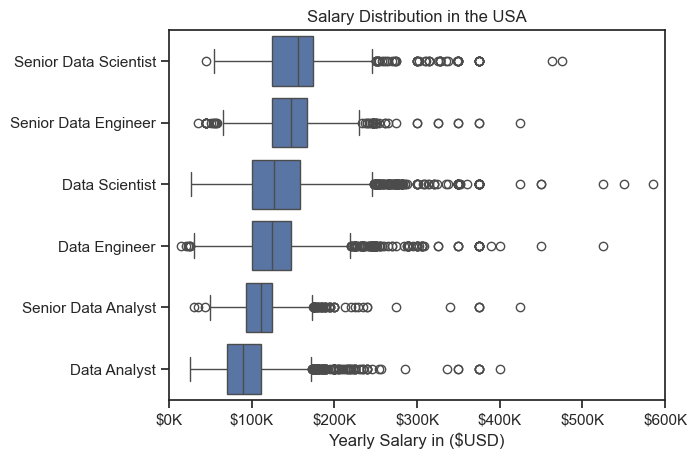

In [29]:
sns.boxplot(data=df_US_top6, x='salary_year_avg', y='job_title_short', order=job_order)
sns.set_theme(style='ticks')

plt.title("Salary Distribution in the USA")
plt.xlabel('Yearly Salary in ($USD)')
plt.ylabel('')
plt.xlim(0, 600000)
ticks_x = plt.FuncFormatter(lambda y, pos: f'${(y/1000):.0f}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()

## Investigate Median Salary Vs Skills for Data Analysts

In [39]:
df_US_DA = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')].copy()
df_US_DA = df_US_DA.dropna(subset=['salary_year_avg'])
df_US_DA = df_US_DA.explode('job_skills')

In [54]:
df_DA_top_pay = df_US_DA.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='median', ascending=False)
df_DA_top_pay = df_DA_top_pay.head(10)


In [58]:
df_DA_skills = df_US_DA.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)
df_DA_skills = df_DA_skills.head(10).sort_values(by='median', ascending=False)

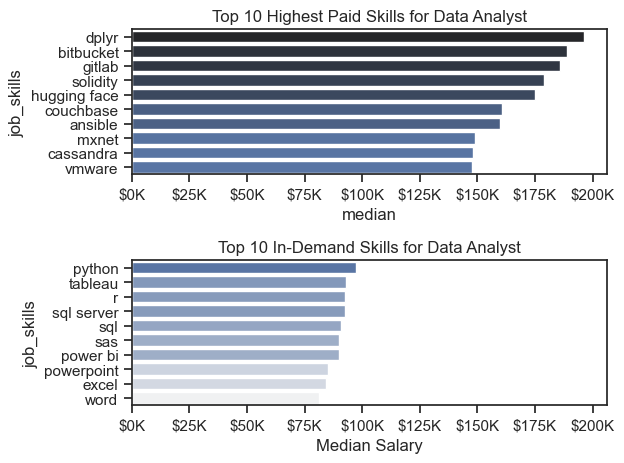

In [60]:
# plotting with seaborn
fig, ax = plt.subplots(2, 1)
sns.set_theme(style="ticks")

# highest paying
sns.barplot(data=df_DA_top_pay, x='median', y=df_DA_top_pay.index, ax=ax[0], hue='median', palette='dark:b_r')
#df_DA_top_pay[::-1].plot(kind='barh', y='median', legend=False, ax=ax[0])
ax[0].legend().remove()
ax[0].set_title("Top 10 Highest Paid Skills for Data Analyst")
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

# most in-demand
sns.barplot(data=df_DA_skills, x='median', y=df_DA_skills.index, ax=ax[1], hue='median', palette='light:b')
#df_DA_skills[::-1].plot(kind='barh', y='median', legend=False, ax=ax[1])
ax[1].legend().remove()
ax[1].set_title("Top 10 In-Demand Skills for Data Analyst")
ax[1].set_xlabel("Median Salary")
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

# match x-axis
ax[1].set_xlim(ax[0].get_xlim())

fig.tight_layout()
plt.show()